# 02 — Sentinel-2 Rectangle-based Land Cover Classification

## ผลของรูปแบบ Training Sample ต่อการจำแนกสิ่งปกคลุมดิน
**Google Earth Engine Python API + Google Colab**

**พื้นที่ศึกษา:** อำเภอเมืองพิษณุโลก จังหวัดพิษณุโลก  
**ข้อมูล:** Sentinel-2 Surface Reflectance, มกราคม 2021  
**ระดับ:** ปริญญาตรีปี 3–4 / ปริญญาโทด้านสิ่งแวดล้อม

Notebook นี้ต่อจาก Notebook 01 โดยเปลี่ยนเพียงสิ่งสำคัญหนึ่งอย่าง:

```text
Notebook 01              Notebook 02
Training Point    →      Training Rectangle
     ●                   ┌────────┐
                         │   ●    │
                         └────────┘
```

ส่วนข้อมูล Sentinel-2, predictor variables, Random Forest และ validation points จะคงเดิมให้มากที่สุด

## Learning objectives

เมื่อจบ Notebook นี้ ผู้เรียนควรสามารถ

1. อธิบายความหมายของ **spatial support** ของ training sample
2. แปลง training point เป็น rectangular training window
3. อธิบายความเสี่ยงของ mixed pixel และ edge effect
4. แยกความแตกต่างระหว่าง **training locations** กับ **training pixels**
5. อธิบายว่าทำไม pixels จำนวนมากไม่ได้หมายถึง independent samples จำนวนมาก
6. จำแนก LULC ด้วย Random Forest จาก rectangle training
7. ใช้ validation points ชุดเดิมเปรียบเทียบ Point vs Rectangle classification
8. ส่งออกผล Rectangle classification เป็น GeoTIFF สำหรับ QGIS

## Controlled experiment

เราจะพยายามให้ทุกอย่างเหมือน Notebook 01

| Component | Point model | Rectangle model |
|---|---|---|
| Study area | Same | Same |
| Sentinel-2 period | Same | Same |
| Spectral predictors | Same | Same |
| Indices | Same | Same |
| Random Forest | 100 trees | 100 trees |
| Training locations | Same | Same |
| Validation locations | Same | Same |
| Training geometry | **Point** | **20 × 20 m rectangle** |

ดังนั้นคำถามหลักคือ

> **เมื่อเปลี่ยนเฉพาะ spatial representation ของ training data ผลจำแนกเปลี่ยนไปอย่างไร?**

In [1]:
# Import libraries

import ee
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

print("Earth Engine API version:", ee.__version__)
print("Folium version:", folium.__version__)

Earth Engine API version: 1.7.39
Folium version: 0.20.0


In [2]:
# Authenticate and initialize Google Earth Engine

PROJECT = "teach-gee-github-lulc"

ee.Authenticate()
ee.Initialize(project=PROJECT)

print("Earth Engine initialized successfully.")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine initialized successfully.


In [3]:
# Mapping helpers and class definitions

def add_ee_layer(map_object, ee_image, vis_params, name,
                 shown=True, opacity=1.0):
    map_id = ee.Image(ee_image).getMapId(vis_params)

    folium.raster_layers.TileLayer(
        tiles=map_id["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True,
        show=shown,
        opacity=opacity,
    ).add_to(map_object)


def add_esri_imagery(map_object, shown=False):
    folium.TileLayer(
        tiles=(
            "https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}"
        ),
        attr="Esri, Maxar, Earthstar Geographics, and the GIS User Community",
        name="Esri World Imagery",
        overlay=False,
        control=True,
        show=shown,
    ).add_to(map_object)


CLASS_COLORS = {
    0: "#d73027",
    1: "#2166ac",
    2: "#1a9850",
    3: "#fee08b",
    4: "#a6611a",
}

CLASS_NAMES = {
    0: "Urban",
    1: "Water",
    2: "Forest",
    3: "Agriculture",
    4: "Bare soil",
}

CLASS_ORDER = [0, 1, 2, 3, 4]

CLASS_PALETTE = [
    CLASS_COLORS[i].replace("#", "")
    for i in CLASS_ORDER
]

SEED = 42

# Part 1 — Load the same reference dataset

เราจะใช้ reference points ชุดเดียวกับ Notebook 01

จำนวนรวม 101 จุด และใช้ **fixed split เดิม**

```text
Training locations   = 71
Validation locations = 30
```

สำคัญมาก:

> Notebook 02 **ห้าม random split ใหม่**

เพราะ validation set ต้องเหมือนเดิมเพื่อให้เปรียบเทียบกับ Notebook 01 ได้อย่างยุติธรรม

In [4]:
# Load the same reference CSV used in Notebook 01

LOCAL_CSV = Path("/content/phitsanulok_lulc_points.csv")

GITHUB_CSV = (
    "https://raw.githubusercontent.com/"
    "nattaponm/Teach-GEE-LULC/main/"
    "data/phitsanulok_lulc_points.csv"
)

if LOCAL_CSV.exists():
    samples_df = pd.read_csv(LOCAL_CSV)
    print("Loaded:", LOCAL_CSV)
else:
    try:
        samples_df = pd.read_csv(GITHUB_CSV)
        print("Loaded from GitHub:", GITHUB_CSV)
    except Exception:
        print(
            "CSV was not found on GitHub yet.\n"
            "Upload phitsanulok_lulc_points.csv to Colab."
        )
        from google.colab import files

        uploaded = files.upload()
        filename = next(iter(uploaded))
        samples_df = pd.read_csv(filename)

samples_df["class_id"] = samples_df["class_id"].astype(int)

display(samples_df.head())

Loaded from GitHub: https://raw.githubusercontent.com/nattaponm/Teach-GEE-LULC/main/data/phitsanulok_lulc_points.csv


,sample_id,longitude,latitude,class_id,class_name,split
0,UR001,100.269879,16.817238,0,Urban,train
1,UR002,100.285468,16.817505,0,Urban,validation
2,UR003,100.256249,16.804334,0,Urban,validation
3,UR004,100.279540,16.782361,0,Urban,train
4,UR005,100.197563,16.753218,0,Urban,validation


In [5]:
# Check that the fixed split is still intact

if "split" not in samples_df.columns:
    raise ValueError(
        "The CSV must contain the fixed 'split' column created in Notebook 01."
    )

split_table = pd.crosstab(
    samples_df["class_name"],
    samples_df["split"],
    margins=True,
)

display(split_table)

print("Training locations:",
      (samples_df["split"] == "train").sum())

print("Validation locations:",
      (samples_df["split"] == "validation").sum())

split,train,validation,All
class_name,,,
Agriculture,14,6,20
Bare soil,15,6,21
Forest,14,6,20
Urban,14,6,20
Water,14,6,20
All,71,30,101


Training locations: 71
Validation locations: 30


In [6]:
# Convert pandas DataFrame to Earth Engine FeatureCollection

def dataframe_to_ee_points(df):
    features = []

    for row in df.itertuples(index=False):
        geometry = ee.Geometry.Point(
            [float(row.longitude), float(row.latitude)]
        )

        properties = {
            "sample_id": str(row.sample_id),
            "longitude": float(row.longitude),
            "latitude": float(row.latitude),
            "class_id": int(row.class_id),
            "class_name": str(row.class_name),
            "split": str(row.split),
        }

        features.append(
            ee.Feature(geometry, properties)
        )

    return ee.FeatureCollection(features)


all_points = dataframe_to_ee_points(samples_df)

training_points = all_points.filter(
    ee.Filter.eq("split", "train")
)

validation_points = all_points.filter(
    ee.Filter.eq("split", "validation")
)

print("Training:", training_points.size().getInfo())
print("Validation:", validation_points.size().getInfo())

Training: 71
Validation: 30


# Part 2 — Spatial support

ใน Notebook 01 training sample เป็น **Point**

ในเชิง geometry

$$
A_{point} \approx 0
$$

แต่ใน Notebook 02 เราจะสร้างพื้นที่สี่เหลี่ยมรอบตำแหน่งเดิม

ถ้า

$$
w=h=20\,m
$$

พื้นที่ของ training window คือ

$$
A_{window}=w\times h
$$

ดังนั้น

$$
A_{window}=20\times20=400\,m^2
$$

สำหรับ Sentinel-2 pixel ขนาดประมาณ 10 m:

$$
A_{pixel}=10\times10=100\,m^2
$$

จำนวน pixel 10-m โดยประมาณภายใน window คือ

$$
n\approx\frac{A_{window}}{A_{pixel}}
=
\frac{400}{100}
\approx4
$$

แต่จำนวนจริงอาจต่างจาก 4 เพราะ pixel-grid alignment, projection และ masking

## ทำไมเริ่มที่ 20 × 20 m?

เป้าหมายไม่ได้ต้องการให้ rectangle ใหญ่ที่สุด

เราต้องการ

```text
เพิ่ม spectral observations
          แต่
ยังรักษา class purity
```

ถ้า window ใหญ่เกินไปอาจคร่อม

- Urban ↔ Bare soil
- Water ↔ Bank
- Agriculture ↔ Road / bund
- Forest ↔ Agriculture

ดังนั้น **20 × 20 m** ใช้เป็น operational teaching window สำหรับชุดข้อมูลนี้

> Rectangle ในบทนี้คือ **point-derived training window**  
> ไม่ใช่ manually digitized homogeneous training polygon

In [7]:
# Convert TRAINING points only to approximately 20 × 20 m rectangles
#
# Buffer radius = 10 m, then use the bounding rectangle.
# Validation samples remain POINTS.

HALF_SIZE_M = 10

def point_to_training_rectangle(feature):
    feature = ee.Feature(feature)

    rectangle = (
        feature.geometry()
        .buffer(HALF_SIZE_M)
        .bounds(maxError=1)
    )

    return ee.Feature(
        rectangle,
        feature.toDictionary()
    )


training_rectangles = training_points.map(
    point_to_training_rectangle
)

print("Training points:",
      training_points.size().getInfo())

print("Training rectangles:",
      training_rectangles.size().getInfo())

print("Validation points remain:",
      validation_points.size().getInfo())

Training points: 71
Training rectangles: 71
Validation points remain: 30


In [8]:
# Map 1 — Inspect the geometry transformation

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=13,
    tiles=None,
)

add_esri_imagery(Map, shown=True)

training_group = folium.FeatureGroup(
    name="Original training points",
    show=True,
)

train_df = samples_df[
    samples_df["split"] == "train"
].copy()

for row in train_df.itertuples(index=False):
    color = CLASS_COLORS[int(row.class_id)]

    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        tooltip=f"{row.sample_id} | {row.class_name}",
    ).add_to(training_group)

training_group.add_to(Map)

rectangle_style = training_rectangles.style(
    color="FFFF00",
    fillColor="FFFF0020",
    width=2,
)

add_ee_layer(
    Map,
    rectangle_style,
    {},
    "20 × 20 m training windows",
    shown=True,
)

folium.LayerControl(collapsed=False).add_to(Map)

Map

# Part 3 — Mixed pixel and edge effect

การขยายจุดให้เป็นพื้นที่ช่วยเก็บ spectral variability ได้มากขึ้น  
แต่เพิ่มความเสี่ยงที่พื้นที่ตัวอย่างจะมีมากกว่าหนึ่ง land-cover class

แนวคิด spectral mixture แบบง่าย:

$$
R_{pixel}
\approx
\sum_{k=1}^{K} f_kR_k
$$

โดย

$$
\sum_{k=1}^{K}f_k=1
$$

ตัวอย่าง:

```text
70% Bare soil
30% Vegetation
```

pixel ที่ sensor วัดจะไม่ใช่ bare soil บริสุทธิ์และไม่ใช่ vegetation บริสุทธิ์

### Edge effect

Training window ที่อยู่ใกล้ขอบเขตระหว่างสอง classes มีโอกาสรับ pixel ที่ไม่ได้เป็น class เดียวกับ label

ดังนั้น

$$
\text{more training pixels}
\ne
\text{better training data}
$$

## Mini QC activity

ก่อน train model ให้ zoom เข้าไปตรวจ training windows บางจุด

โดยเฉพาะ

- Urban
- Water
- Bare soil

ลองตอบ:

1. Rectangle อยู่บน land cover เดียวทั้งหมดหรือไม่?
2. Water rectangle คร่อมตลิ่งหรือไม่?
3. Urban rectangle มี vegetation หรือ open land แทรกหรือไม่?
4. Bare-soil rectangle อยู่ใกล้ built-up หรือ road หรือไม่?

> การตรวจ training geometry เป็นส่วนหนึ่งของ Remote Sensing interpretation

# Part 4 — Prepare the same Sentinel-2 predictor stack

เพื่อให้เป็น controlled experiment เราจะใช้ preprocessing และ predictors ชุดเดิมจาก Notebook 01

$$
\mathbf{x}_{S2}
=
[
B2,B3,B4,B8,B11,B12,
NDVI,NDWI,NDBI
]
$$

ไม่มีการเปลี่ยน sensor, date หรือ predictor variables

In [9]:
# Study area

roi = ee.Geometry.Point([100.26575, 16.82277])

gaul2 = (
    ee.FeatureCollection("FAO/GAUL/2025/level2")
    .filter(ee.Filter.eq("GAUL0_NAME", "Thailand"))
)

district_fc = gaul2.filterBounds(roi)
study_area = district_fc.geometry()

print("District candidate(s):")
display(district_fc.aggregate_array("DISP_EN").getInfo())

District candidate(s):


['Mueang Phitsanulok, Phitsanulok, Thailand']

In [10]:
# Prepare Sentinel-2 exactly as in Notebook 01

START_DATE = "2021-01-01"
END_DATE = "2021-02-01"

SPECTRAL_BANDS = [
    "B2", "B3", "B4", "B8", "B11", "B12"
]

s2_raw = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(study_area)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 50))
)

def mask_s2_scl(image):
    scl = image.select("SCL")

    mask = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    return (
        image
        .updateMask(mask)
        .select(SPECTRAL_BANDS)
        .multiply(0.0001)
        .copyProperties(image, ["system:time_start"])
    )


s2 = (
    s2_raw
    .map(mask_s2_scl)
    .median()
    .clip(study_area)
)

print("Sentinel-2 scenes:",
      s2_raw.size().getInfo())

Sentinel-2 scenes: 14


In [11]:
# Create spectral indices and predictor image

ndvi = s2.normalizedDifference(
    ["B8", "B4"]
).rename("NDVI")

ndwi = s2.normalizedDifference(
    ["B3", "B8"]
).rename("NDWI")

ndbi = s2.normalizedDifference(
    ["B11", "B8"]
).rename("NDBI")

PREDICTOR_BANDS = [
    "B2", "B3", "B4",
    "B8", "B11", "B12",
    "NDVI", "NDWI", "NDBI"
]

predictors = (
    s2
    .addBands([ndvi, ndwi, ndbi])
    .select(PREDICTOR_BANDS)
)

display(predictors.bandNames().getInfo())

['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI']

In [12]:
# Map 2 — Inspect rectangles against Sentinel-2

true_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0.02,
    "max": 0.30,
    "gamma": 1.1,
}

veg_vis = {
    "bands": ["B8", "B4", "B3"],
    "min": 0.02,
    "max": 0.35,
    "gamma": 1.1,
}

urban_vis = {
    "bands": ["B12", "B11", "B4"],
    "min": 0.02,
    "max": 0.35,
    "gamma": 1.1,
}

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=12,
    tiles=None,
)

add_esri_imagery(Map, shown=False)
add_ee_layer(Map, s2, true_vis, "S2 True Color", shown=True)
add_ee_layer(Map, s2, veg_vis, "S2 Vegetation False Color", shown=False)
add_ee_layer(Map, s2, urban_vis, "S2 Urban/Bare False Color", shown=False)

add_ee_layer(
    Map,
    rectangle_style,
    {},
    "20 × 20 m training windows",
    shown=True,
)

folium.LayerControl(collapsed=False).add_to(Map)

Map

# Part 5 — From training locations to training pixels

ใน Notebook 01:

```text
1 training point
      ↓
ประมาณ 1 sampled pixel
```

ใน Notebook 02:

```text
1 training rectangle
      ↓
หลาย sampled pixels
```

ดังนั้นต้องแยกสองคำนี้ให้ชัด

- **Training location** = ตำแหน่งอ้างอิงเชิงภูมิศาสตร์
- **Training pixel** = pixel ที่ถูกดึงค่าจาก image เพื่อใช้ train classifier

จำนวน training pixels อาจเพิ่มขึ้นมาก  
แต่จำนวน independent geographical training locations ยังเท่าเดิม

In [13]:
# Sample predictor pixels inside the 20 × 20 m training windows

rectangle_training_data = predictors.sampleRegions(
    collection=training_rectangles,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

print("Independent training locations:",
      training_rectangles.size().getInfo())

print("Training pixel records after sampling:",
      rectangle_training_data.size().getInfo())

print("\nPixel records by class:")
display(
    rectangle_training_data
    .aggregate_histogram("class_id")
    .getInfo()
)

Independent training locations: 71
Training pixel records after sampling: 262

Pixel records by class:


{'0': 56, '1': 56, '2': 28, '3': 58, '4': 64}

In [14]:
# Count sampled pixels contributed by each source rectangle

sample_ids = (
    rectangle_training_data
    .aggregate_array("sample_id")
    .getInfo()
)

pixel_counts = (
    pd.Series(sample_ids, name="sample_id")
    .value_counts()
    .rename("n_pixels")
    .reset_index()
)

pixel_counts = (
    pixel_counts
    .merge(
        samples_df[
            ["sample_id", "class_id", "class_name"]
        ],
        on="sample_id",
        how="left",
    )
    .sort_values(
        ["class_id", "sample_id"]
    )
)

display(pixel_counts.head(20))

print("\nPixels per training window:")
display(
    pixel_counts["n_pixels"].describe()
)

,sample_id,n_pixels,class_id,class_name
3,UR001,4,0,Urban
5,UR004,4,0,Urban
6,UR006,4,0,Urban
7,UR007,4,0,Urban
4,UR008,4,0,Urban
13,UR010,4,0,Urban
14,UR011,4,0,Urban
15,UR012,4,0,Urban
8,UR013,4,0,Urban
9,UR015,4,0,Urban



Pixels per training window:


,n_pixels
count,64.000000
mean,4.093750
std,0.426084
min,4.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,6.000000


## Pixels are not independent locations

ถ้า rectangle หนึ่งให้ข้อมูล 4 pixels

```text
■ ■
■ ■
```

ไม่ได้แปลว่าเราเพิ่ม independent reference locations จาก 1 เป็น 4

pixel ที่อยู่ใกล้กันมักมี spatial dependence

ดังนั้น

$$
n_{pixels}
\ne
n_{independent\ geographical\ samples}
$$

สำหรับ Notebook นี้ เรายังมี **71 independent training locations** เท่าเดิม

สิ่งที่เพิ่มขึ้นคือจำนวน spectral observations ภายในบริเวณรอบตำแหน่งเหล่านั้น

# Part 6 — Train Rectangle-based Random Forest

เราจะใช้ Random Forest เหมือน Notebook 01

```text
numberOfTrees = 100
seed = 42
```

ไม่มี hyperparameter tuning เพื่อให้ตัวแปรทดลองหลักยังคงเป็น **training geometry**

In [15]:
# Train rectangle-based Random Forest

rectangle_classifier = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=100,
        seed=SEED,
    )
    .train(
        features=rectangle_training_data,
        classProperty="class_id",
        inputProperties=PREDICTOR_BANDS,
    )
)

print("Rectangle-based Random Forest trained.")

Rectangle-based Random Forest trained.


In [16]:
# Create rectangle-based classification map

rectangle_classified = (
    predictors
    .classify(rectangle_classifier)
    .rename("landcover")
    .clip(study_area)
)

print("Rectangle classification created.")

Rectangle classification created.


In [17]:
# Map 3 — Rectangle-based classification

class_vis = {
    "min": 0,
    "max": 4,
    "palette": CLASS_PALETTE,
}

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=10,
    tiles=None,
)

add_esri_imagery(Map, shown=False)
add_ee_layer(Map, s2, true_vis, "S2 True Color", shown=True)

add_ee_layer(
    Map,
    rectangle_classified,
    class_vis,
    "S2 Rectangle RF Classification",
    shown=True,
)

legend_html = '''
<div style="
position: fixed;
bottom: 30px;
left: 30px;
z-index: 9999;
background-color: white;
padding: 10px;
border: 1px solid grey;
font-size: 13px;">
<b>LULC classes</b><br>
<span style="color:#d73027;">●</span> 0 Urban<br>
<span style="color:#2166ac;">●</span> 1 Water<br>
<span style="color:#1a9850;">●</span> 2 Forest<br>
<span style="color:#fee08b;">●</span> 3 Agriculture<br>
<span style="color:#a6611a;">●</span> 4 Bare soil
</div>
'''

Map.get_root().html.add_child(
    folium.Element(legend_html)
)

folium.LayerControl(collapsed=False).add_to(Map)

Map

# Part 7 — Validation must remain POINT-based

Validation points ต้องคงเดิมจาก Notebook 01

```text
Rectangle training
        ↓
Random Forest
        ↓
Classification

Same 30 validation POINTS
        ↓
Actual vs Predicted
        ↓
Confusion Matrix
```

เราไม่เปลี่ยน validation points เป็น rectangles เพราะต้องการให้แต่ละ reference location มีน้ำหนักเป็นหนึ่งตำแหน่ง

ถ้า validation rectangle หนึ่งสร้างหลาย pixels แล้วนับทุก pixel เป็น validation record  
จะทำให้จำนวนตัวอย่างดูมากกว่าจำนวน independent locations จริง

In [18]:
# Sample predictors at the SAME validation points

validation_data = predictors.sampleRegions(
    collection=validation_points,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

rectangle_validation = validation_data.classify(
    rectangle_classifier,
    "predicted",
)

print("Validation locations supplied:",
      validation_points.size().getInfo())

print("Validation records retained:",
      validation_data.size().getInfo())

Validation locations supplied: 30
Validation records retained: 27


In [19]:
# Accuracy helper

def accuracy_from_predictions(predictions,
                              actual="class_id",
                              predicted="predicted"):
    cm = predictions.errorMatrix(
        actual,
        predicted,
        CLASS_ORDER,
    )

    cm_array = np.array(
        cm.array().getInfo(),
        dtype=int,
    )

    diag = np.diag(cm_array).astype(float)
    row_sum = cm_array.sum(axis=1).astype(float)
    col_sum = cm_array.sum(axis=0).astype(float)

    pa = np.divide(
        diag,
        row_sum,
        out=np.full_like(diag, np.nan),
        where=row_sum != 0,
    )

    ua = np.divide(
        diag,
        col_sum,
        out=np.full_like(diag, np.nan),
        where=col_sum != 0,
    )

    f1 = np.divide(
        2 * pa * ua,
        pa + ua,
        out=np.full_like(diag, np.nan),
        where=(pa + ua) != 0,
    )

    oa = (
        np.trace(cm_array) / cm_array.sum()
        if cm_array.sum() > 0
        else np.nan
    )

    cm_df = pd.DataFrame(
        cm_array,
        index=[CLASS_NAMES[i] for i in CLASS_ORDER],
        columns=[CLASS_NAMES[i] for i in CLASS_ORDER],
    )

    cm_df.index.name = "Reference / Actual"
    cm_df.columns.name = "Predicted"

    metrics_df = pd.DataFrame({
        "class_id": CLASS_ORDER,
        "class_name": [
            CLASS_NAMES[i]
            for i in CLASS_ORDER
        ],
        "PA": pa,
        "UA": ua,
        "F1": f1,
        "Validation_n": row_sum.astype(int),
    })

    return cm_df, metrics_df, oa

In [20]:
# Rectangle-model validation results

rect_cm, rect_metrics, rect_oa = accuracy_from_predictions(
    rectangle_validation
)

print("Rectangle model — Confusion Matrix")
display(rect_cm)

print(
    "Rectangle model — Overall Accuracy:",
    round(rect_oa, 4)
)

display(
    rect_metrics.style.format({
        "PA": "{:.3f}",
        "UA": "{:.3f}",
        "F1": "{:.3f}",
    })
)

Rectangle model — Confusion Matrix


Predicted,Urban,Water,Forest,Agriculture,Bare soil
Reference / Actual,,,,,
Urban,6,0,0,0,0
Water,0,6,0,0,0
Forest,0,0,2,1,0
Agriculture,0,0,1,5,0
Bare soil,0,1,0,0,5


Rectangle model — Overall Accuracy: 0.8889


,class_id,class_name,PA,UA,F1,Validation_n
0,0,Urban,1.000,1.000,1.000,6
1,1,Water,1.000,0.857,0.923,6
2,2,Forest,0.667,0.667,0.667,3
3,3,Agriculture,0.833,0.833,0.833,6
4,4,Bare soil,0.833,1.000,0.909,6


# Part 8 — Recalculate the Point model as a baseline

เพื่อให้ Notebook 02 รันได้ด้วยตัวเอง  
เราจะสร้าง **Point model แบบย่อ** ด้วยข้อมูลและ parameter เดิมจาก Notebook 01

ไม่มีการสอน concept ใหม่ในส่วนนี้

จุดประสงค์คือให้ได้ comparison ที่ reproducible ภายใน Notebook เดียว

In [21]:
# Point-model baseline using the same training locations

point_training_data = predictors.sampleRegions(
    collection=training_points,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

point_classifier = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=100,
        seed=SEED,
    )
    .train(
        features=point_training_data,
        classProperty="class_id",
        inputProperties=PREDICTOR_BANDS,
    )
)

point_validation = validation_data.classify(
    point_classifier,
    "predicted",
)

point_cm, point_metrics, point_oa = accuracy_from_predictions(
    point_validation
)

print(
    "Point model — Overall Accuracy:",
    round(point_oa, 4)
)

Point model — Overall Accuracy: 0.9259


In [22]:
# Compare Point vs Rectangle

comparison = pd.DataFrame({
    "Metric": ["Overall Accuracy"],
    "Point": [point_oa],
    "Rectangle": [rect_oa],
})

class_comparison = (
    point_metrics[
        ["class_name", "F1"]
    ]
    .rename(columns={"F1": "Point_F1"})
    .merge(
        rect_metrics[
            ["class_name", "F1"]
        ].rename(
            columns={"F1": "Rectangle_F1"}
        ),
        on="class_name",
    )
)

class_comparison["Change"] = (
    class_comparison["Rectangle_F1"]
    - class_comparison["Point_F1"]
)

display(
    comparison.style.format({
        "Point": "{:.3f}",
        "Rectangle": "{:.3f}",
    })
)

display(
    class_comparison.style.format({
        "Point_F1": "{:.3f}",
        "Rectangle_F1": "{:.3f}",
        "Change": "{:+.3f}",
    })
)

,Metric,Point,Rectangle
0,Overall Accuracy,0.926,0.889


,class_name,Point_F1,Rectangle_F1,Change
0,Urban,1.000,1.000,+0.000
1,Water,1.000,0.923,-0.077
2,Forest,0.667,0.667,+0.000
3,Agriculture,0.833,0.833,+0.000
4,Bare soil,1.000,0.909,-0.091


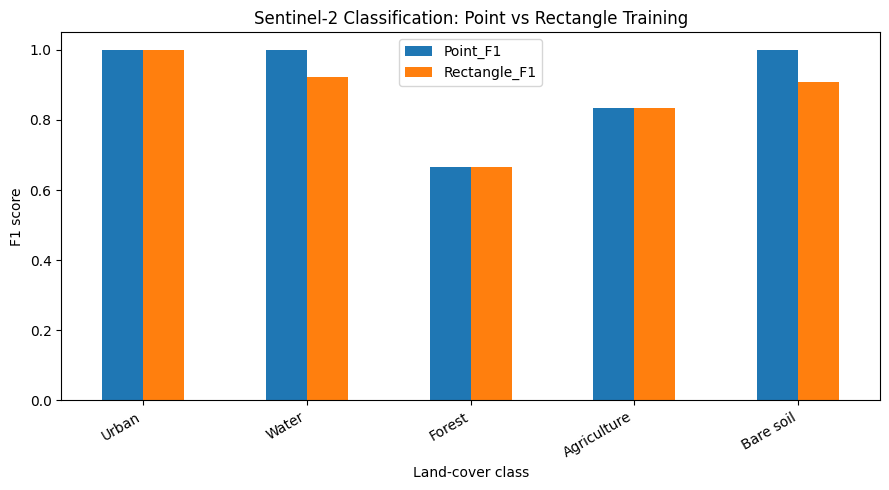

In [23]:
# Simple comparison plot

plot_df = class_comparison.set_index("class_name")[
    ["Point_F1", "Rectangle_F1"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Sentinel-2 Classification: Point vs Rectangle Training"
)

ax.set_xlabel("Land-cover class")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Interpretation questions

อย่าดูเฉพาะ Overall Accuracy

ตอบคำถามต่อไปนี้

1. Rectangle training เพิ่มจำนวน training pixel records เท่าใด?
2. Overall Accuracy เพิ่มหรือลดจาก Point model?
3. Class ใดมี F1 ดีขึ้นมากที่สุด?
4. Class ใดมี F1 ลดลง?
5. Urban–Bare soil confusion เปลี่ยนหรือไม่?
6. Forest–Agriculture confusion เปลี่ยนหรือไม่?
7. Rectangle ที่คร่อมขอบเขต land cover อาจอธิบาย error บางส่วนได้หรือไม่?
8. จำนวน training pixels เพิ่มขึ้น แต่ผลไม่ดีขึ้นเสมอไปเพราะอะไร?

### หลักสำคัญ

$$
\text{Training quantity}
\ne
\text{Training quality}
$$

# Part 9 — Export Rectangle classification for QGIS

จะ export เป็น

```text
PHS_S2_Rectangle_RF_LULC_2021.tif
```

ใช้ class coding เดิม

```text
0 = Urban
1 = Water
2 = Forest
3 = Agriculture
4 = Bare soil
255 = NoData
```

เพื่อให้เปิดเปรียบเทียบกับ Point classification จาก Notebook 01 ใน QGIS ได้โดยตรง

In [24]:
# Export rectangle-based classification as GeoTIFF

NO_DATA = 255

rectangle_export = (
    rectangle_classified
    .toByte()
    .unmask(NO_DATA)
)

export_task = ee.batch.Export.image.toDrive(
    image=rectangle_export,
    description="PHS_S2_Rectangle_RF_LULC_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S2_Rectangle_RF_LULC_2021",
    region=study_area,
    scale=10,
    crs="EPSG:32647",
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True,
        "noData": NO_DATA,
    },
)

export_task.start()

print("Rectangle GeoTIFF export task started.")
print(export_task.status())

Rectangle GeoTIFF export task started.
{'state': 'READY', 'description': 'PHS_S2_Rectangle_RF_LULC_2021', 'priority': 100, 'creation_timestamp_ms': 1791274896577, 'update_timestamp_ms': 1791274896577, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'Q3Q7NLRFNIEGPI53KEB4ZDJ5', 'name': 'projects/teach-gee-github-lulc/operations/Q3Q7NLRFNIEGPI53KEB4ZDJ5'}


In [25]:
# Optional: export the 20 × 20 m training windows for inspection in QGIS

rectangle_vector_task = ee.batch.Export.table.toDrive(
    collection=training_rectangles,
    description="PHS_LULC_Training_Rectangles_20m",
    folder="GEE_LULC",
    fileNamePrefix="PHS_LULC_Training_Rectangles_20m",
    fileFormat="GeoJSON",
    selectors=[
        "sample_id",
        "class_id",
        "class_name",
        "split",
    ],
)

rectangle_vector_task.start()

print("Training rectangle export task started.")
print(rectangle_vector_task.status())

Training rectangle export task started.
{'state': 'READY', 'description': 'PHS_LULC_Training_Rectangles_20m', 'priority': 100, 'creation_timestamp_ms': 1791274899314, 'update_timestamp_ms': 1791274899314, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'OHF2I4AERBQIBQZ3KDEUPTFJ', 'name': 'projects/teach-gee-github-lulc/operations/OHF2I4AERBQIBQZ3KDEUPTFJ'}


# Exercise — Does a larger window always help?

ทดลองเปลี่ยน training window เป็น

```text
10 × 10 m
20 × 20 m
30 × 30 m
```

แล้วบันทึกผล

| Training support | Area | Training pixel records | OA | Mean F1 |
|---|---:|---:|---:|---:|
| Point | — | — | | |
| 10 × 10 m | 100 m² | | | |
| 20 × 20 m | 400 m² | | | |
| 30 × 30 m | 900 m² | | | |

### คำถาม

1. Window ที่ใหญ่ที่สุดให้ accuracy สูงที่สุดหรือไม่?
2. Class ใด sensitive ต่อ window size มากที่สุด?
3. Water หรือ Urban มีปัญหา edge effect มากกว่ากัน?
4. Window size ที่เหมาะสมควรพิจารณาอะไรนอกจาก accuracy?

In [26]:
# Exercise helper
#
# half_size_m = 5  -> approximately 10 × 10 m
# half_size_m = 10 -> approximately 20 × 20 m
# half_size_m = 15 -> approximately 30 × 30 m

def make_training_rectangles(
    point_collection,
    half_size_m
):
    def _convert(feature):
        feature = ee.Feature(feature)

        geometry = (
            feature.geometry()
            .buffer(half_size_m)
            .bounds(maxError=1)
        )

        return ee.Feature(
            geometry,
            feature.toDictionary()
        )

    return point_collection.map(_convert)


# Example:
# rectangles_10m = make_training_rectangles(training_points, 5)
# rectangles_20m = make_training_rectangles(training_points, 10)
# rectangles_30m = make_training_rectangles(training_points, 15)

# Take-home messages

1. Point และ rectangle มี **spatial support** ต่างกัน
2. Rectangle training สามารถเพิ่ม spectral observations ได้
3. Training pixels หลาย pixel จากพื้นที่เดียวกันไม่ใช่ independent locations หลายแห่ง
4. Rectangle ใหญ่เกินไปเพิ่มความเสี่ยงต่อ mixed pixels และ mislabeled pixels
5. Validation points ต้องคง independent จาก training geometry
6. การเปรียบเทียบ model ที่ดีควรเปลี่ยนทีละปัจจัย
7. More pixels ไม่ได้หมายถึง better training data
8. ในงานจริง polygon training ควรวาดภายในพื้นที่ homogeneous และตรวจคุณภาพด้วยภาพหลายแบบ

## Next

**Notebook 03 — Sentinel-1 SAR Fundamentals**

Notebook ถัดไปจะยังไม่ classify ทันที แต่จะเรียนก่อนว่า

- SAR เป็น active sensor อย่างไร
- VV / VH หมายถึงอะไร
- backscatter และ dB คืออะไร
- speckle คืออะไร
- temporal backscatter ของ land cover เปลี่ยนอย่างไร

# References and documentation

- Google Earth Engine — Sentinel-2 SR Harmonized  
  https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED

- Google Earth Engine — `sampleRegions()`  
  https://developers.google.com/earth-engine/apidocs/ee-image-sampleregions

- Google Earth Engine — Random Forest  
  https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest

- Google Earth Engine — Error Matrix  
  https://developers.google.com/earth-engine/apidocs/ee-featurecollection-errormatrix

- Google Earth Engine — Export image to Drive  
  https://developers.google.com/earth-engine/apidocs/export-image-todrive